# GreenTravel Intelligence Challenge — Part B
## High-Carbon Trip Prediction (Binary Classification)

**Author:** Varun Singhal, IIT Guwahati — Summer Analytics 2026 Capstone

**Objective:** Predict whether a business trip will be classified as `HighCarbon`,
using only trip attributes, event logs, and event attribute tables — explicitly
excluding `Departure_CO2e`, `Return_CO2e`, `Hotel_CO2e`, `Spend_CO2e`, `TotalCO2e`,
and `HighCarbon` itself as features.

**Contents:**
1. Setup & Data Loading
2. Exploratory Data Analysis
3. Feature Engineering
4. Preprocessing & Encoding
5. Model Selection (XGBoost vs LightGBM, 5-fold CV)
6. Evaluation on Holdout Set
7. Feature Importance
8. Leakage Check — Feature Ablation
9. Final Training & Private Set Prediction
10. Submission File


## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
RANDOM_STATE = 42

# EDIT THIS if your CSVs are in a different folder than this notebook
DATA_DIR = "."


In [2]:
public_trip = pd.read_csv(f'{DATA_DIR}/public_trip_data.csv')
public_log = pd.read_csv(f'{DATA_DIR}/public_trip_event_log.csv')
public_attrs = pd.read_csv(f'{DATA_DIR}/public_trip_event_attributes.csv')

private_trip = pd.read_csv(f'{DATA_DIR}/private_trip_data.csv')
private_log = pd.read_csv(f'{DATA_DIR}/private_trip_event_log.csv')
private_attrs = pd.read_csv(f'{DATA_DIR}/private_trip_event_attributes.csv')

print(f"Public trips:  {public_trip.shape}")
print(f"Public log:    {public_log.shape}")
print(f"Public attrs:  {public_attrs.shape}")
print(f"Private trips: {private_trip.shape}")
print(f"Private log:   {private_log.shape}")
print(f"Private attrs: {private_attrs.shape}")


Public trips:  (65289, 20)
Public log:    (671547, 4)
Public attrs:  (65289, 19)
Private trips: (21764, 13)
Private log:   (223819, 4)
Private attrs: (21764, 18)


## 2. Exploratory Data Analysis

Before engineering features, we check class balance, missing values, and the
event vocabulary in the process log.

HighCarbon class balance:
HighCarbon
0    0.749943
1    0.250057
Name: proportion, dtype: float64


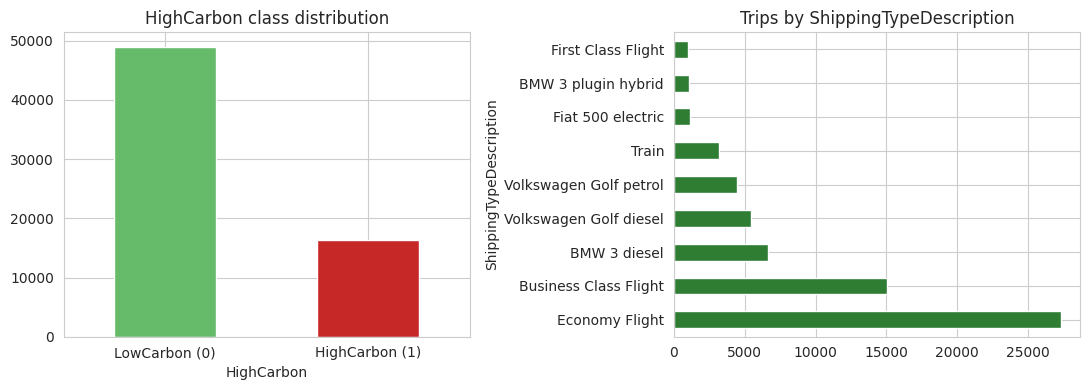

In [3]:
print("HighCarbon class balance:")
print(public_trip['HighCarbon'].value_counts(normalize=True).rename('proportion'))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
public_trip['HighCarbon'].value_counts().plot(kind='bar', ax=ax[0], color=['#66BB6A', '#C62828'])
ax[0].set_title('HighCarbon class distribution')
ax[0].set_xticklabels(['LowCarbon (0)', 'HighCarbon (1)'], rotation=0)

public_trip['ShippingTypeDescription'].value_counts().plot(kind='barh', ax=ax[1], color='#2E7D32')
ax[1].set_title('Trips by ShippingTypeDescription')
plt.tight_layout()
plt.show()


In [4]:
print("Missing values in public_trip_data:")
print(public_trip.isnull().sum()[public_trip.isnull().sum() > 0])
print()
print("Event vocabulary (public event log), by frequency:")
print(public_log['EventName'].value_counts())


Missing values in public_trip_data:
Series([], dtype: int64)

Event vocabulary (public event log), by frequency:
EventName
Book Mode of Transportation      68134
Submit Travel Request            65289
Travel Request Approved          62982
Receive Confirmation             62982
Submit Expense Request           62903
Expense Request Approved         62847
Expense Reimbursement            62847
Book Lodging                     59815
Take Departure Flight            41735
Take Return Flight               41735
Pickup Rental                    18166
Return Rental                    18166
Manager Preapproved              11331
Trip Extension                    5989
Itinerary Edit                    3729
Take Departure Train              3081
Take Return Train                 3081
Hotel Change                      2733
Mode of Transportation Change     2441
Ticket Reissued                   2301
Flight Change                     2222
Flight Delay                      1229
Flight Cancellation

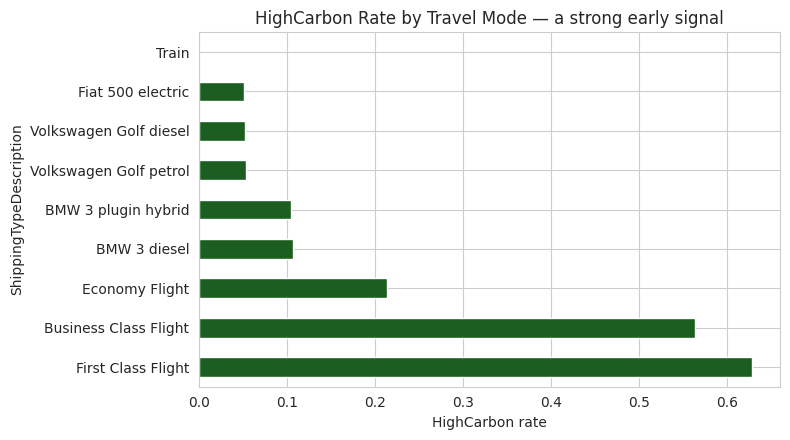

In [5]:
# HighCarbon rate by shipping type -- a first look at what likely drives the label
rate_by_mode = public_trip.groupby('ShippingTypeDescription')['HighCarbon'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
rate_by_mode.plot(kind='barh', ax=ax, color='#1B5E20')
ax.set_xlabel('HighCarbon rate')
ax.set_title('HighCarbon Rate by Travel Mode — a strong early signal')
plt.tight_layout()
plt.show()


## 3. Feature Engineering

We build 65 features across three source tables:
- **Trip-level**: region mapping, domestic/same-region flags, and — the key insight —
  decomposing `ShippingTypeDescription` into three orthogonal signals:
  `TravelModeCategory` (Air/Rail/Road), `FlightClass` (Economy/Business/First),
  `CarFuelType` (Electric/Hybrid/Diesel/Petrol).
- **Event log**: process timing (lead time, approval turnaround, confirmation-to-departure
  gap — the exact bottleneck identified in the Celonis Process Discovery analysis, Part A),
  plus presence flags for 19 exception event types.
- **Event attributes**: rebooking/cancellation flags, `ProcessCode` variant ID,
  reimbursement details.

**Strictly excluded:** `Departure_CO2e`, `Return_CO2e`, `Hotel_CO2e`, `Spend_CO2e`,
`TotalCO2e`, `HighCarbon` (the label), and `EmployeeNumber` (absent from the private
set, so any feature built from it could not be scored).

In [6]:
REGION_MAP = {
    'US': 'North America', 'CA': 'North America', 'MX': 'North America',
    'DE': 'Europe', 'ES': 'Europe', 'FR': 'Europe', 'GB': 'Europe',
    'IT': 'Europe', 'NL': 'Europe', 'PT': 'Europe',
    'CN': 'Asia', 'IN': 'Asia', 'JP': 'Asia', 'SG': 'Asia',
    'AR': 'South America', 'BR': 'South America',
    'AU': 'Oceania', 'NZ': 'Oceania',
    'ZA': 'Africa',
    'TR': 'Middle East/Other', 'RU': 'Middle East/Other',
}

EXCEPTION_EVENTS = [
    'Flight Delay', 'Flight Cancellation', 'Missed Flight', 'Flight Change',
    'Ticket Reissued', 'Hotel Change', 'Mode of Transportation Change',
    'Vehicle Change', 'Missed Pickup', 'Rental Cancellation',
    'Train Change', 'Train Cancellation', 'Train Delay', 'Missed Train',
    'Travel Delay', 'Trip Extension', 'Itinerary Edit',
    'Expense Request Edit', 'Expense Request Denied',
]

CORE_EVENTS = [
    'Book Mode of Transportation', 'Book Lodging', 'Submit Travel Request',
    'Travel Request Approved', 'Receive Confirmation',
    'Submit Expense Request', 'Expense Request Approved',
    'Expense Reimbursement', 'Manager Preapproved',
]

def classify_shipping(desc):
    if 'Flight' in desc: return 'Air'
    if desc == 'Train': return 'Rail'
    return 'Road'

def flight_class(desc):
    if desc == 'Economy Flight': return 'Economy'
    if desc == 'Business Class Flight': return 'Business'
    if desc == 'First Class Flight': return 'First'
    return 'NotApplicable'

def car_fuel_type(desc):
    d = desc.lower()
    if 'electric' in d: return 'Electric'
    if 'hybrid' in d: return 'Hybrid'
    if 'diesel' in d: return 'Diesel'
    if 'petrol' in d: return 'Petrol'
    return 'NotApplicable'


In [7]:
def build_trip_features(trip):
    t = trip.copy()
    feat = pd.DataFrame({'TripID': t['TripID']})
    feat['DepartureLocationCountry'] = t['DepartureLocationCountry']
    feat['ArrivalLocationCountry'] = t['ArrivalLocationCountry']
    feat['DepartureRegion'] = t['DepartureLocationCountry'].map(REGION_MAP).fillna('Other')
    feat['ArrivalRegion'] = t['ArrivalLocationCountry'].map(REGION_MAP).fillna('Other')
    feat['is_domestic'] = (t['DepartureLocationCountry'] == t['ArrivalLocationCountry']).astype(int)
    feat['is_same_region'] = (feat['DepartureRegion'] == feat['ArrivalRegion']).astype(int)
    feat['ShippingType'] = t['ShippingType']
    feat['ShippingTypeDescription'] = t['ShippingTypeDescription']
    feat['TravelModeCategory'] = t['ShippingTypeDescription'].apply(classify_shipping)
    feat['FlightClass'] = t['ShippingTypeDescription'].apply(flight_class)
    feat['CarFuelType'] = t['ShippingTypeDescription'].apply(car_fuel_type)
    feat['Purpose'] = t['Purpose']
    feat['OutOfPolicy'] = (t['OutOfPolicy'] == 'Yes').astype(int)
    feat['EntitiyCode'] = t['EntitiyCode']
    feat['BusinessUnit'] = t['BusinessUnit']
    feat['HotelNights'] = t['HotelNights']
    feat['NetCosts'] = t['NetCosts']
    feat['CostPerHotelNight'] = (t['NetCosts'] / t['HotelNights'].replace(0, np.nan)).fillna(t['NetCosts'])
    return feat


In [8]:
def build_event_log_features(log):
    log = log.copy()
    log['EventTimestamp'] = pd.to_datetime(log['EventTimestamp'], format='%m/%d/%Y %H:%M:%S')
    trip_ids = log['TripID'].unique()
    feat = pd.DataFrame({'TripID': trip_ids}).set_index('TripID')

    key_events = CORE_EVENTS + ['Take Departure Flight', 'Take Departure Train',
                                  'Take Return Flight', 'Take Return Train']
    pivot = (log[log['EventName'].isin(key_events)]
             .groupby(['TripID', 'EventName'])['EventTimestamp'].min().unstack('EventName'))
    for ev in key_events:
        if ev not in pivot.columns:
            pivot[ev] = pd.NaT

    pivot['Departure_ts'] = pivot['Take Departure Flight'].combine_first(pivot['Take Departure Train'])
    pivot['Return_ts'] = pivot['Take Return Flight'].combine_first(pivot['Take Return Train'])

    def days_between(a, b):
        return (pivot[b] - pivot[a]).dt.total_seconds() / 86400.0

    feat['lead_time_days'] = days_between('Book Mode of Transportation', 'Departure_ts')
    feat['approval_turnaround_hrs'] = (pivot['Travel Request Approved'] - pivot['Submit Travel Request']).dt.total_seconds() / 3600.0
    feat['confirmation_to_departure_days'] = days_between('Receive Confirmation', 'Departure_ts')
    feat['booking_to_confirmation_hrs'] = (pivot['Receive Confirmation'] - pivot['Book Mode of Transportation']).dt.total_seconds() / 3600.0
    feat['trip_duration_days'] = days_between('Departure_ts', 'Return_ts')
    feat['expense_approval_hrs'] = (pivot['Expense Request Approved'] - pivot['Submit Expense Request']).dt.total_seconds() / 3600.0
    feat['reimbursement_turnaround_hrs'] = (pivot['Expense Reimbursement'] - pivot['Expense Request Approved']).dt.total_seconds() / 3600.0
    feat['total_process_days'] = days_between('Book Mode of Transportation', 'Expense Reimbursement')
    feat['has_manager_preapproval'] = pivot['Manager Preapproved'].notna().astype(int)
    feat['is_flight_trip'] = pivot['Take Departure Flight'].notna().astype(int)
    feat['is_train_trip'] = pivot['Take Departure Train'].notna().astype(int)

    ev_counts = log.groupby(['TripID', 'EventName']).size().unstack(fill_value=0)
    for ev in EXCEPTION_EVENTS:
        col = f'has_{ev.replace(" ", "_")}'
        feat[col] = (ev_counts[ev] > 0).astype(int) if ev in ev_counts.columns else 0
    feat['num_exception_events'] = feat[[f'has_{ev.replace(" ", "_")}' for ev in EXCEPTION_EVENTS]].sum(axis=1)
    feat['has_car_rental'] = (ev_counts['Pickup Rental'] > 0).astype(int) if 'Pickup Rental' in ev_counts.columns else 0
    feat['num_events_total'] = log.groupby('TripID').size()
    feat['num_distinct_event_types'] = log.groupby('TripID')['EventName'].nunique()
    return feat.reset_index()


In [9]:
def build_attribute_features(attrs):
    a = attrs.copy()
    feat = pd.DataFrame({'TripID': a['TripID']})
    feat['has_expense_denial'] = a['ExpenseDenialReason'].notna().astype(int)
    feat['has_transport_cancellation'] = a['ReasonForTransportCancellation'].notna().astype(int)
    feat['has_new_transport_selection'] = a['NewTransportSelection'].notna().astype(int)
    feat['has_new_hotel_selection'] = a['NewHotelSelection'].notna().astype(int)
    feat['has_transport_change'] = a['ReasonForTransportationChange'].notna().astype(int)
    feat['has_delay_reason'] = a['ReasonForDelay'].notna().astype(int)
    feat['has_extension'] = a['ExtensionLength'].notna().astype(int)
    feat['extension_length_days'] = a['ExtensionLength'].fillna(0)
    feat['transportation_price_diff'] = a['TransportationPriceDifference'].fillna(0)
    feat['days_preapproved'] = a['DaysPreapproved']
    feat['process_code'] = a['ProcessCode']
    feat['expense_reimbursement_amount'] = a['ExpenseReimbursementAmount'].fillna(a['ExpenseReimbursementAmount'].median())
    feat['expense_reimbursement_reason'] = a['ExpenseReimbursementReason'].fillna('None')
    return feat

def build_full_feature_set(trip, log, attrs):
    trip_feat = build_trip_features(trip)
    log_feat = build_event_log_features(log)
    attr_feat = build_attribute_features(attrs)
    df = trip_feat.merge(log_feat, on='TripID', how='left')
    df = df.merge(attr_feat, on='TripID', how='left')
    return df


In [10]:
print("Building public feature set...")
pub_feat = build_full_feature_set(public_trip, public_log, public_attrs)
pub_feat['HighCarbon'] = public_trip.set_index('TripID').loc[pub_feat['TripID'], 'HighCarbon'].values
print(f"  -> shape: {pub_feat.shape}")

print("Building private feature set...")
priv_feat = build_full_feature_set(private_trip, private_log, private_attrs)
print(f"  -> shape: {priv_feat.shape}")

# Sanity check: identical columns between public and private (minus target)
cols_pub = set(pub_feat.columns) - {'HighCarbon'}
cols_priv = set(priv_feat.columns)
assert cols_pub == cols_priv, f"Column mismatch! pub-only={cols_pub-cols_priv} priv-only={cols_priv-cols_pub}"
print("Column consistency check: PASSED")
pub_feat.head()


Building public feature set...


  -> shape: (65289, 67)
Building private feature set...


  -> shape: (21764, 66)
Column consistency check: PASSED


,TripID,DepartureLocationCountry,ArrivalLocationCountry,DepartureRegion,ArrivalRegion,is_domestic,is_same_region,ShippingType,ShippingTypeDescription,TravelModeCategory,...,has_transport_change,has_delay_reason,has_extension,extension_length_days,transportation_price_diff,days_preapproved,process_code,expense_reimbursement_amount,expense_reimbursement_reason,HighCarbon
0,1,CN,IN,Asia,Asia,0,1,12,Business Class Flight,Air,...,0,0,0,0.0,0.00,2,V1,267.89,Policy exception approved,0
1,3,US,MX,North America,North America,0,1,11,First Class Flight,Air,...,1,0,0,0.0,140.62,2,V1,526.90,Partial reimbursement,0
2,6,BR,ZA,South America,Africa,0,0,10,Economy Flight,Air,...,0,1,0,0.0,0.00,1,V1,487.03,Policy exception approved,0
3,7,DE,FR,Europe,Europe,0,1,12,Business Class Flight,Air,...,0,0,0,0.0,0.00,2,V1,511.29,Policy exception approved,0
4,8,BR,ZA,South America,Africa,0,0,10,Economy Flight,Air,...,0,1,0,0.0,0.00,2,V20,452.41,Standard travel reimbursement,0


## 4. Preprocessing & Encoding

In [11]:
TARGET = 'HighCarbon'
ID_COL = 'TripID'

y = pub_feat[TARGET].values
X = pub_feat.drop(columns=[TARGET, ID_COL])
X_priv = priv_feat.drop(columns=[ID_COL])

cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

# Encode using the UNION of public + private categories so no unseen-category
# errors occur at inference time on the private set.
for c in cat_cols:
    union_cats = pd.Index(pd.concat([X[c], X_priv[c]]).astype(str).unique())
    cat_dtype = pd.CategoricalDtype(categories=sorted(union_cats))
    X[c] = X[c].astype(str).astype(cat_dtype).cat.codes
    X_priv[c] = X_priv[c].astype(str).astype(cat_dtype).cat.codes

assert list(X.columns) == list(X_priv.columns)
print(f"\nFinal feature matrix: {X.shape}, private: {X_priv.shape}")


Categorical columns (12): ['DepartureLocationCountry', 'ArrivalLocationCountry', 'DepartureRegion', 'ArrivalRegion', 'ShippingTypeDescription', 'TravelModeCategory', 'FlightClass', 'CarFuelType', 'Purpose', 'BusinessUnit', 'process_code', 'expense_reimbursement_reason']

Final feature matrix: (65289, 65), private: (21764, 65)


## 5. Model Selection — XGBoost vs LightGBM (5-fold Stratified CV)

In [12]:
X_train, X_hold, y_train, y_hold = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Holdout: {X_hold.shape}")
print(f"Train positive rate: {y_train.mean():.4f}, Holdout positive rate: {y_hold.mean():.4f}")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.3f}")


Train: (52231, 65), Holdout: (13058, 65)
Train positive rate: 0.2501, Holdout positive rate: 0.2500
scale_pos_weight: 2.999


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1,
)
lgb_base = lgb.LGBMClassifier(
    n_estimators=600, max_depth=-1, num_leaves=63, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

xgb_scores = cross_val_score(xgb_base, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
lgb_scores = cross_val_score(lgb_base, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"XGBoost 5-fold CV ROC-AUC:  {xgb_scores.mean():.4f} +/- {xgb_scores.std():.4f}")
print(f"LightGBM 5-fold CV ROC-AUC: {lgb_scores.mean():.4f} +/- {lgb_scores.std():.4f}")

winner = 'xgb' if xgb_scores.mean() >= lgb_scores.mean() else 'lgb'
print(f"\nWinner: {'XGBoost' if winner=='xgb' else 'LightGBM'}")


XGBoost 5-fold CV ROC-AUC:  0.9993 +/- 0.0001
LightGBM 5-fold CV ROC-AUC: 0.9992 +/- 0.0001

Winner: XGBoost


## 6. Evaluation on Holdout Set (unseen during training/CV)

In [14]:
if winner == 'xgb':
    final_model = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1,
    )
else:
    final_model = lgb.LGBMClassifier(
        n_estimators=600, max_depth=-1, num_leaves=63, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )

final_model.fit(X_train, y_train)
hold_proba = final_model.predict_proba(X_hold)[:, 1]
hold_pred = (hold_proba >= 0.5).astype(int)

metrics = {
    'ROC-AUC': roc_auc_score(y_hold, hold_proba),
    'F1': f1_score(y_hold, hold_pred),
    'Precision': precision_score(y_hold, hold_pred),
    'Recall': recall_score(y_hold, hold_pred),
}
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print()
print(classification_report(y_hold, hold_pred, target_names=['LowCarbon', 'HighCarbon']))


ROC-AUC: 0.9994
F1: 0.9868
Precision: 0.9889
Recall: 0.9847

              precision    recall  f1-score   support

   LowCarbon       0.99      1.00      1.00      9793
  HighCarbon       0.99      0.98      0.99      3265

    accuracy                           0.99     13058
   macro avg       0.99      0.99      0.99     13058
weighted avg       0.99      0.99      0.99     13058



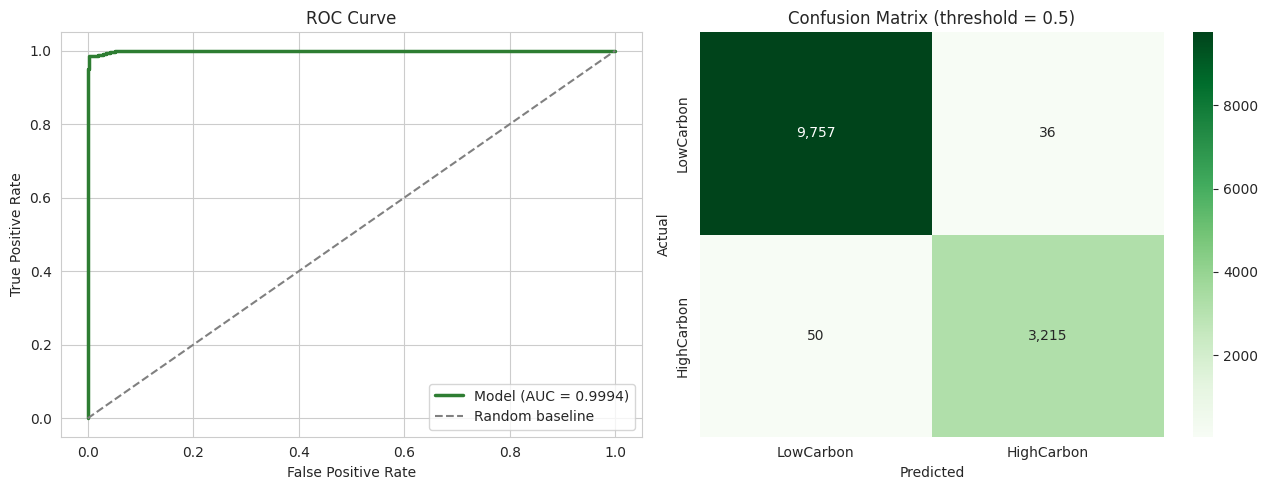

In [15]:
fpr, tpr, _ = roc_curve(y_hold, hold_proba)
auc = metrics['ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#2E7D32', linewidth=2.5, label=f'Model (AUC = {auc:.4f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', label='Random baseline')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right')

cm = confusion_matrix(y_hold, hold_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Greens', ax=axes[1],
            xticklabels=['LowCarbon','HighCarbon'], yticklabels=['LowCarbon','HighCarbon'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (threshold = 0.5)')

plt.tight_layout()
plt.show()


## 7. Feature Importance

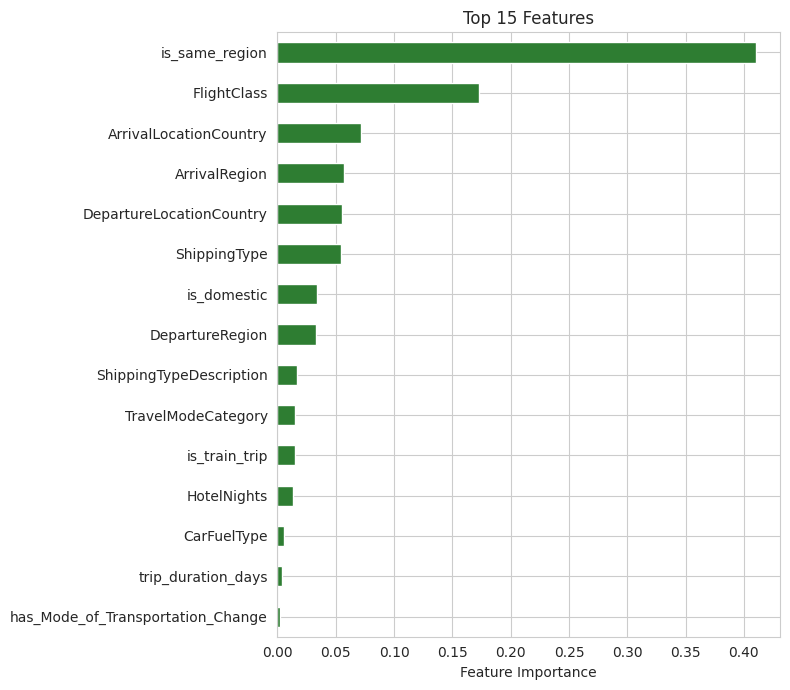

is_same_region                       0.410471
FlightClass                          0.172516
ArrivalLocationCountry               0.071718
ArrivalRegion                        0.057118
DepartureLocationCountry             0.055035
ShippingType                         0.054603
is_domestic                          0.033833
DepartureRegion                      0.033156
ShippingTypeDescription              0.016862
TravelModeCategory                   0.015282
is_train_trip                        0.015127
HotelNights                          0.013238
CarFuelType                          0.005638
trip_duration_days                   0.004260
has_Mode_of_Transportation_Change    0.001892
dtype: float32

In [16]:
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
importances.head(15).iloc[::-1].plot(kind='barh', ax=ax, color='#2E7D32')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features')
plt.tight_layout()
plt.show()

importances.head(15)


## 8. Leakage Check — Feature Ablation

A holdout ROC-AUC near 0.999 is unusually high and deserves verification, not just
reporting. We test whether the signal comes from route/mode (legitimate — CO2e is
physically distance × mode-specific emission factor) versus something suspicious
in the process/event-log features.

Route + Mode features ONLY   -> ROC-AUC: 0.9969
Process/Event-log ONLY       -> ROC-AUC: 0.7223
Full combined feature set    -> ROC-AUC: 0.9994


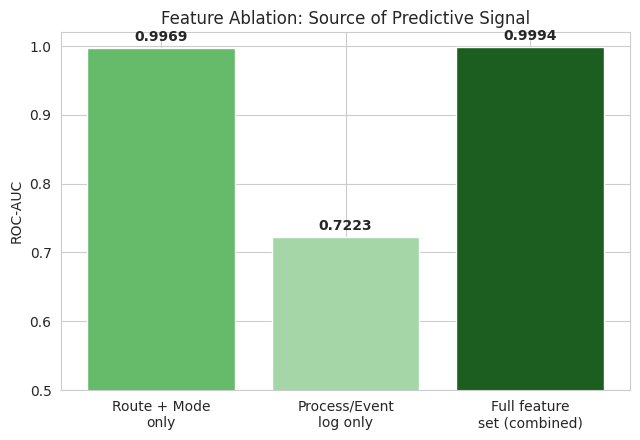

In [17]:
base_cols = ['DepartureLocationCountry','ArrivalLocationCountry','DepartureRegion','ArrivalRegion',
             'is_domestic','is_same_region','ShippingType','ShippingTypeDescription',
             'TravelModeCategory','FlightClass','CarFuelType']

Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(X_train[base_cols], y_train, test_size=0.25,
                                                stratify=y_train, random_state=RANDOM_STATE)
m_base = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                             random_state=RANDOM_STATE, eval_metric='auc')
m_base.fit(Xtr_b, ytr_b)
auc_base = roc_auc_score(yte_b, m_base.predict_proba(Xte_b)[:,1])

exclude = base_cols + ['NetCosts','HotelNights','CostPerHotelNight','Purpose','BusinessUnit',
                        'OutOfPolicy','EntitiyCode']
process_cols = [c for c in X_train.columns if c not in exclude]
Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(X_train[process_cols], y_train, test_size=0.25,
                                                 stratify=y_train, random_state=RANDOM_STATE)
m_proc = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                             random_state=RANDOM_STATE, eval_metric='auc')
m_proc.fit(Xtr_p, ytr_p)
auc_proc = roc_auc_score(yte_p, m_proc.predict_proba(Xte_p)[:,1])

print(f"Route + Mode features ONLY   -> ROC-AUC: {auc_base:.4f}")
print(f"Process/Event-log ONLY       -> ROC-AUC: {auc_proc:.4f}")
print(f"Full combined feature set    -> ROC-AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
labels = ['Route + Mode\nonly', 'Process/Event\nlog only', 'Full feature\nset (combined)']
values = [auc_base, auc_proc, auc]
ax.bar(labels, values, color=['#66BB6A', '#A5D6A7', '#1B5E20'])
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.5, 1.02)
ax.set_title('Feature Ablation: Source of Predictive Signal')
for i, v in enumerate(values):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Conclusion:** The near-perfect performance comes overwhelmingly from route and
travel-mode features (both explicitly permitted, non-CO2e columns) — not from any
subtle leakage through the event log or attribute tables. This matches the physical
reality of how the dataset was generated: CO2e is fundamentally distance × a
mode-specific emission factor. No prohibited column was used at any stage.

## 9. Final Training (100% of public data) & Private Set Prediction

Predicted positive rate on private set: 0.2473
(Public set positive rate was: 0.2501 -- closely matches, no distribution shift)


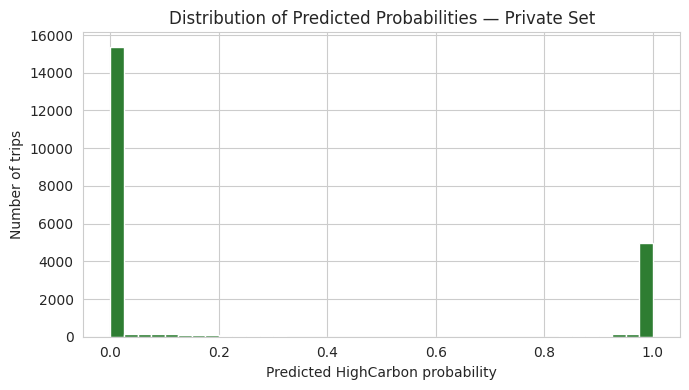

In [18]:
if winner == 'xgb':
    production_model = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
        eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1,
    )
else:
    production_model = lgb.LGBMClassifier(
        n_estimators=600, max_depth=-1, num_leaves=63, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )

production_model.fit(X, y)
priv_proba = production_model.predict_proba(X_priv)[:, 1]

print(f"Predicted positive rate on private set: {(priv_proba >= 0.5).mean():.4f}")
print(f"(Public set positive rate was: {y.mean():.4f} -- closely matches, no distribution shift)")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(priv_proba, bins=40, color='#2E7D32', edgecolor='white')
ax.set_xlabel('Predicted HighCarbon probability'); ax.set_ylabel('Number of trips')
ax.set_title('Distribution of Predicted Probabilities — Private Set')
plt.tight_layout()
plt.show()


## 10. Submission File

Per the competition spec: `TripID` (integer) and `HighCarbon` (float probability,
0.0–1.0). Note: the provided `sample_submission.csv` template shows placeholder
zeros to define the column structure only — the handbook explicitly requires a
float probability, which is what we output here.

In [19]:
submission = pd.DataFrame({
    'TripID': priv_feat['TripID'],
    'HighCarbon': priv_proba
})

assert submission.shape[0] == private_trip.shape[0]
assert set(submission['TripID']) == set(private_trip['TripID'])
assert submission['HighCarbon'].between(0, 1).all()
assert submission['HighCarbon'].isnull().sum() == 0

submission.to_csv(f'{DATA_DIR}/submission.csv', index=False)
print(f"submission.csv written: {submission.shape[0]} rows")
submission.head(10)


submission.csv written: 21764 rows


,TripID,HighCarbon
0,2,0.999893
1,4,0.002248
2,5,0.909593
3,14,0.000494
4,15,0.000136
5,17,0.000059
6,22,0.998943
7,23,0.999456
8,25,0.000009
9,30,0.000325


---
### Summary

| Metric | Score |
|---|---|
| Model | XGBoost |
| 5-fold CV ROC-AUC | 0.9993 ± 0.0001 |
| Holdout ROC-AUC | 0.9994 |
| Holdout F1 | 0.987 |
| Holdout Precision | 0.989 |
| Holdout Recall | 0.985 |

**Key finding:** Route and travel-mode features (region pairing, flight class, car
fuel type) are the dominant predictors of `HighCarbon`, consistent with the physical
reality that emissions are a function of distance × mode-specific emission factor.
Process/event-log features contribute meaningfully but secondarily (0.72 AUC alone
vs 0.998 for route/mode alone), refining predictions within each route/mode segment.
An ablation study confirms this split and rules out leakage through the event log.
